# Extensive benchmarking for DD

#### Circuit : Quantum Volume depth = 2

#### Qubits  : [5, 8, 11, 14, 17, 20]

#### Types
- Only opt 3 transpilation
- opt 3 + ASAP
- opt 3 + ALAP
- opt 3 + ASAP + DD(xx)
- opt 3 + ALAP + DD(xx)
- opt 3 + ASAP + DD(xpxm)
- opt 3 + ALAP + DD(xpxm)
- opt 3 + ASAP + DD(xy)
- opt 3 + ALAP + DD(xy)

#### Iterations : 3 


## Necessary Imports, Functions and Utils

In [1]:
import dill
from qiskit.circuit.library import QuantumVolume
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, YGate
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
from qiskit_ibm_runtime import IBMBackend
from qiskit.visualization import timeline_drawer
from qiskit.transpiler import Target

In [50]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def quantum_volume(qubit:int, depth:int):

    qc = QuantumVolume(qubit, 2, seed=42069)

    qc.measure_all()

    return qc



class BenchmarkOptions:
    def __init__(
        self, 
        backend_name: str = "ibm_fez", 
        opt_level: int = 3, 
        do_dd: bool = False,
        scheduling_method: str | None = None, 
        dd_pulse: str | None = None
    ):
        # Allow any backend 
        try:
            self.backend = QiskitRuntimeService().backend(backend_name)
        except Exception as e:
            print(f"Warning: Could not connect to backend '{backend_name}'. {e}")
            self.backend = None

        self.opt_level = opt_level
        self.do_dd = do_dd
        self.dd_pulse = dd_pulse
        self.scheduling_method = scheduling_method
        self.basis_gates = list(self.backend.target.operation_names)

        ## Default pulse sequence is xx
        if self.do_dd and self.dd_pulse is None:
            self.dd_pulse = 'xx'

        


def pm_for_backend(bknd, opt_level:int, seed:int, scheduling_method:str = "none", target:Target | None = None):
    ## Returns a normal (no dd) PassManager from generate_preset_pass_manager for given opt_level and backend(bknd) al
    
    if target is None:
        target = bknd.target
        
    ## for no scheduling case
    if scheduling_method == 'none':
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    
    ## for "alap" and "asap" cases
    else:
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=scheduling_method, target=target)
    
    return pm


def make_passmanager(benchmark_options:BenchmarkOptions):
    
    backend = benchmark_options.backend if benchmark_options.backend else QiskitRuntimeService().backend("ibm_fez")
    opt_level = benchmark_options.opt_level if benchmark_options.opt_level else 3
    scheduling_method = benchmark_options.scheduling_method if benchmark_options.scheduling_method else 'none'

    print(f"Transpilation options:\nbackend:{backend}\noptlevel:{opt_level}\nscheduling:{scheduling_method}\ndo_dd:{benchmark_options.do_dd}\ndd_pulse:{benchmark_options.dd_pulse}")

    ## Fix seed for reprodicubility
    pm_seed = 42069

    ## Include DD
    if benchmark_options.do_dd:
        return prepare_dd_pm(benchmark_options=benchmark_options)

    ## Defaults to no dd PM with opt_level = 3 and given scheduling_method
    else:
        return pm_for_backend(bknd=backend, opt_level=opt_level, seed=pm_seed, scheduling_method=scheduling_method)




def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler

def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(benchmark_options:BenchmarkOptions):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 

    # Default Sequence
    sequenece = [XGate(), XGate()]

    target = benchmark_options.backend.target

    seq = benchmark_options.dd_pulse

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    if seq.lower() == 'xy':
        from qiskit.transpiler import InstructionProperties

        sequenece = [XGate(), YGate(), XGate(), YGate()]

        y_gate_properties = {}

        for qubit in range(target.num_qubits):
            y_gate_properties.update(
                {
                    (qubit,): InstructionProperties(
                        duration=target["x"][(qubit,)].duration,
                        error=target["x"][(qubit,)].error,
                    )
                }
            )
        
        target.add_instruction(YGate(), y_gate_properties)

    


    ## Prepare a preset passmanager for backend optimization_level=3 and target (target is modified if seq = 'xy)
    pm = pm_for_backend(bknd=benchmark_options.backend, opt_level=3, seed=42069, target=target)

    try:
            
        if benchmark_options.scheduling_method:    
                if benchmark_options.scheduling_method == 'asap':
                    pm.scheduling.append(ASAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
                
                elif benchmark_options.scheduling_method == 'alap':
                    pm.scheduling.append(ALAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    except:
        print(f"Error in sequence({seq}) or scheduling method({benchmark_options.scheduling_method})")

    return pm




def mega_transpiler(circuit:QuantumCircuit, dd_pm:StagedPassManager, benchmark_options:BenchmarkOptions) -> QuantumCircuit:
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    ## Final Translation to convert Y gates into basis equivalent gates
    if benchmark_options.do_dd is True:
        if benchmark_options.dd_pulse.lower() == 'xy':
            from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
            from qiskit.transpiler.passes import BasisTranslator
            

            basis_gates = benchmark_options.basis_gates
            

            return BasisTranslator(sel, basis_gates)(isa_dd_circuit)
        else:
            return isa_dd_circuit

    ## Normal case for xx dd and xpxm dd
    else:
        return isa_dd_circuit
    



def get_fidelity_for_circuit(simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [alt_hellinger_results]




    


## Utils

In [3]:
# 2. Save Function (Generic for any object)
def save_object(obj, filename):
    try:
        with open(filename, 'wb') as f:
            dill.dump(obj, f)
        print(f"Object saved to '{filename}'")
    except Exception as e:
        print(f"Error saving object: {e}")

# 3. Load Function
def load_object(filename):
    try:
        with open(filename, 'rb') as f:
            obj = dill.load(f)
        print(f"Object loaded from '{filename}'")
        return obj
    except Exception as e:
        print(f"Error loading object: {e}")

## Prepare circuit

In [4]:
circuit_name = "QV"

qubits = [5, 8, 11, 14, 17, 20]


circuit_dict = {}

for qubit in qubits:
    circuit_dict[qubit] = quantum_volume(qubit, 2)
    

circuit_dict

/tmp/ipykernel_7992/1440744825.py:34: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.
  qc = QuantumVolume(qubit, 2, seed=42069)
/tmp/ipykernel_7992/1440744825.py:34: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.
  qc = QuantumVolume(qubit, 2, seed=42069)


{5: <qiskit.circuit.library.quantum_volume.QuantumVolume at 0x78dc0d0e9f10>,
 8: <qiskit.circuit.library.quantum_volume.QuantumVolume at 0x78dc4016d7d0>,
 11: <qiskit.circuit.library.quantum_volume.QuantumVolume at 0x78dc0f184c90>,
 14: <qiskit.circuit.library.quantum_volume.QuantumVolume at 0x78dbf6a3b950>,
 17: <qiskit.circuit.library.quantum_volume.QuantumVolume at 0x78dbf4c8ce90>,
 20: <qiskit.circuit.library.quantum_volume.QuantumVolume at 0x78dbf47b9690>}

## Backend

In [5]:
service = QiskitRuntimeService(name="qamp-2025-2")

fez = service.backend("ibm_fez")

management.get:WARNING:2025-12-13 00:49:06,026: Loading saved account: qamp-2025-2


## Transpile Circuits

In [6]:

methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]


passmanagers_to_test = {}

options_dict = {}

for method in methods_list:
    
    options_dict[method] = BenchmarkOptions(scheduling_method=method)
    
    passmanagers_to_test[method] = make_passmanager(options_dict[method])



for dd_method in dd_methods_list:
    dd_method_split = dd_method.split("+")
    options_dict[dd_method] = BenchmarkOptions(scheduling_method=dd_method_split[0], do_dd = True, dd_pulse=dd_method_split[2])
    
    passmanagers_to_test[dd_method] = make_passmanager(options_dict[dd_method])



for dd_method in extra_dd_methods_list:
    dd_method_split = dd_method.split("+")
    options_dict[dd_method] = BenchmarkOptions(scheduling_method=dd_method_split[0], do_dd = True, dd_pulse=dd_method_split[2])
    
    passmanagers_to_test[dd_method] = make_passmanager(options_dict[dd_method])



management.get:WARNING:2025-12-13 00:49:11,605: Loading default saved account
management.get:WARNING:2025-12-13 00:49:16,557: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:none
do_dd:False
dd_pulse:None


management.get:WARNING:2025-12-13 00:49:22,435: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:asap
do_dd:False
dd_pulse:None


management.get:WARNING:2025-12-13 00:49:27,619: Loading default saved account


...

Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:alap
do_dd:True
dd_pulse:xpxm


management.get:WARNING:2025-12-13 00:49:50,004: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:asap
do_dd:True
dd_pulse:xpxm


management.get:WARNING:2025-12-13 00:49:54,856: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:asap
do_dd:True
dd_pulse:xy
Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:alap
do_dd:True
dd_pulse:xy


## Main Transpilation

In [7]:
isa_circuits_dict = {}

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

for qubit in qubits:
    isa_circuits_dict[qubit] = {}
    for method in list(passmanagers_to_test.keys()):
        isa_circuits_dict[qubit][method] = mega_transpiler(circuit_dict[qubit], passmanagers_to_test[method], options_dict[method])
        
        

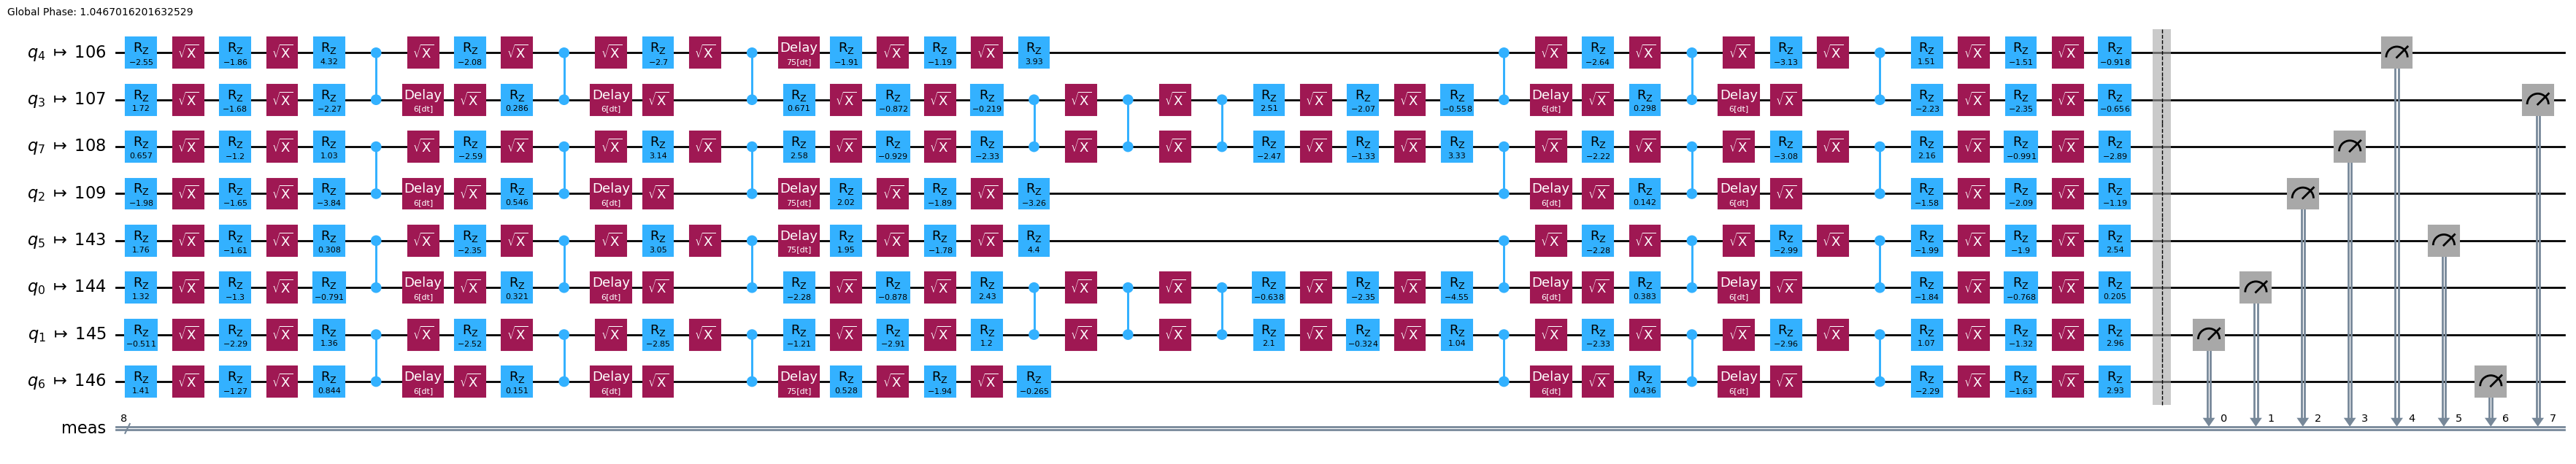

In [8]:
isa_circuits_dict[8]['alap'].draw("mpl",idle_wires=False, fold=-1)

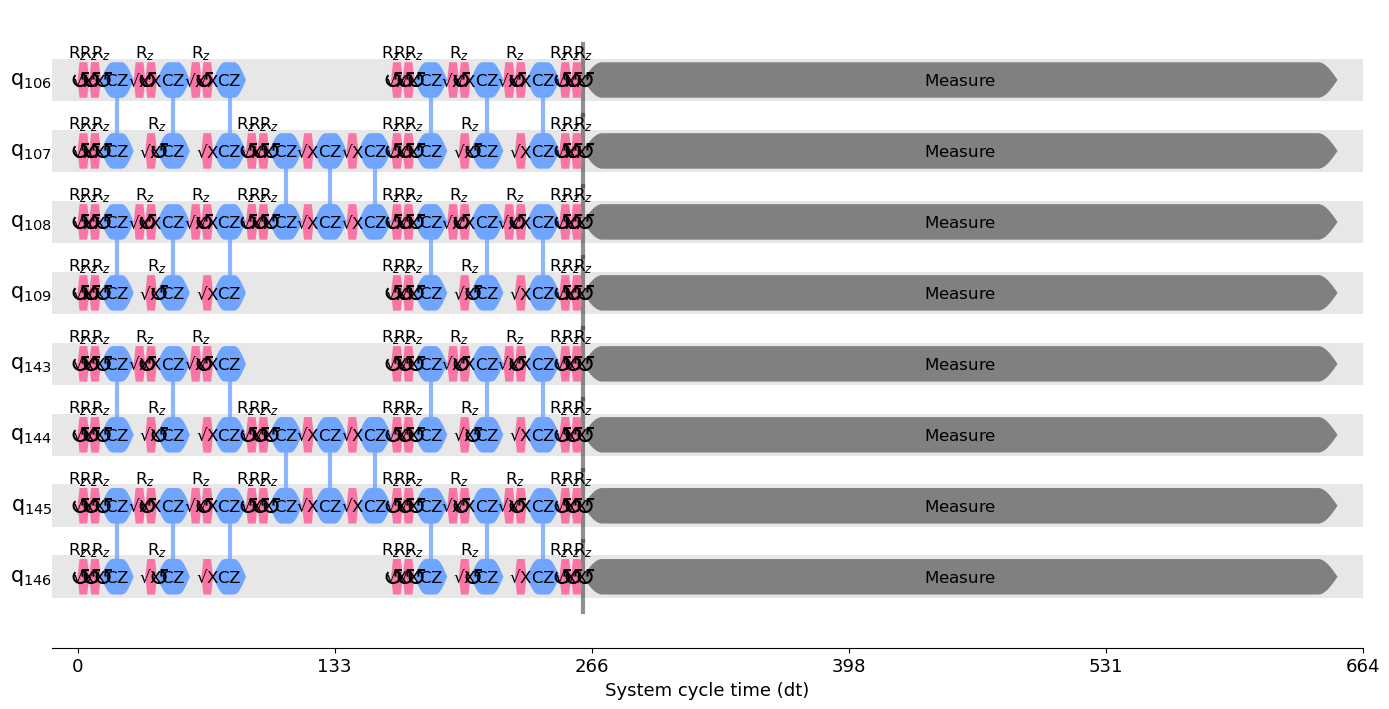

In [9]:
timeline_drawer(isa_circuits_dict[8]['alap'], idle_wires=False, target=fez.target)

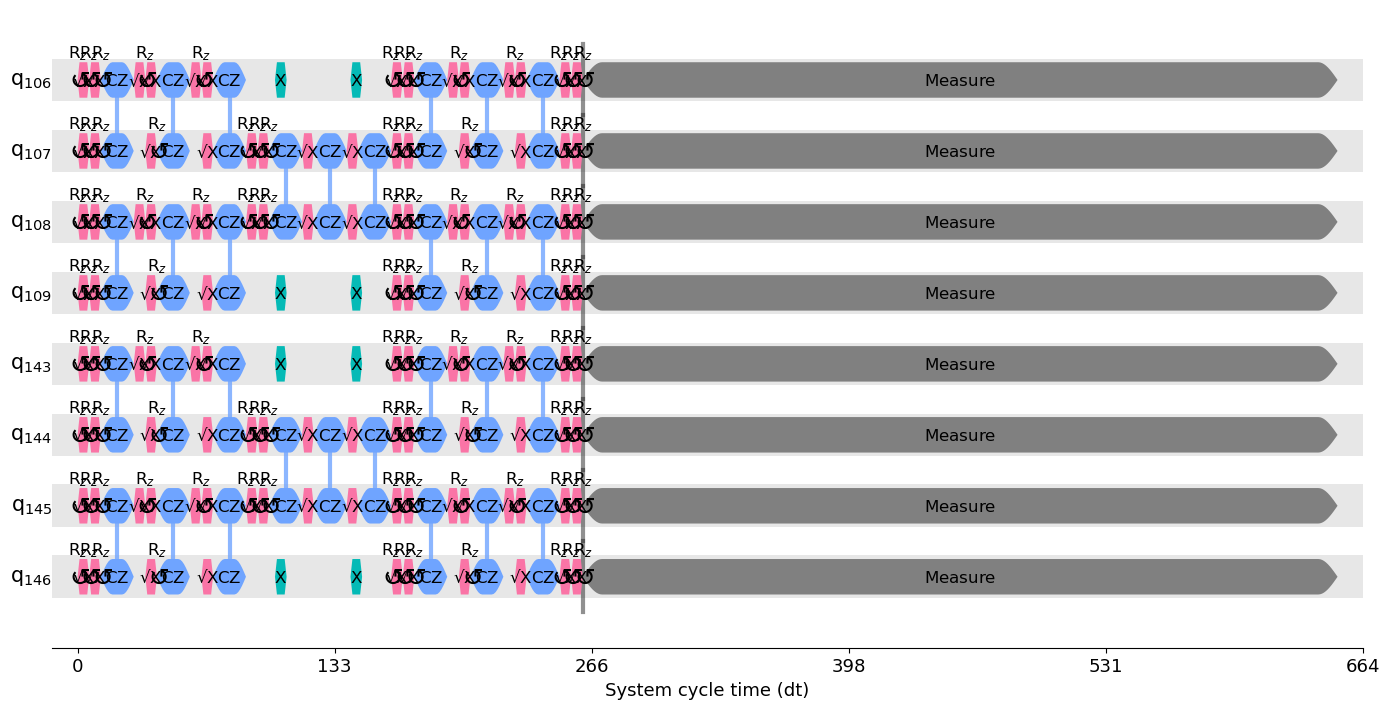

In [10]:
timeline_drawer(isa_circuits_dict[8]['alap+dd+xx'], idle_wires=False, target=fez.target)

In [11]:
## The sampler pub should have all circuit with same num_qubits but different transpilation method. 
## The pubs are in this manner 
##       0               1                 2                3                         4                        5                        6                       
## [ isa_circuit, isa_circuit_asap, isa_circuit_alap, isa_circuit_asap_dd_xx, isa_circuit_alap_dd_xx, isa_circuit_asap_dd_xpxm, isa_circuit_alap_dd_xpxm]


valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

def build_sampler_pub(qubit, valid_methods):
    circuits_dict = isa_circuits_dict[qubit]

    sampler_pub = []

    for method in valid_methods:
        sampler_pub.append( (circuits_dict[method]) )

    return sampler_pub


pubs_dict = {qubit:build_sampler_pub(qubit, valid_methods) for qubit in qubits}




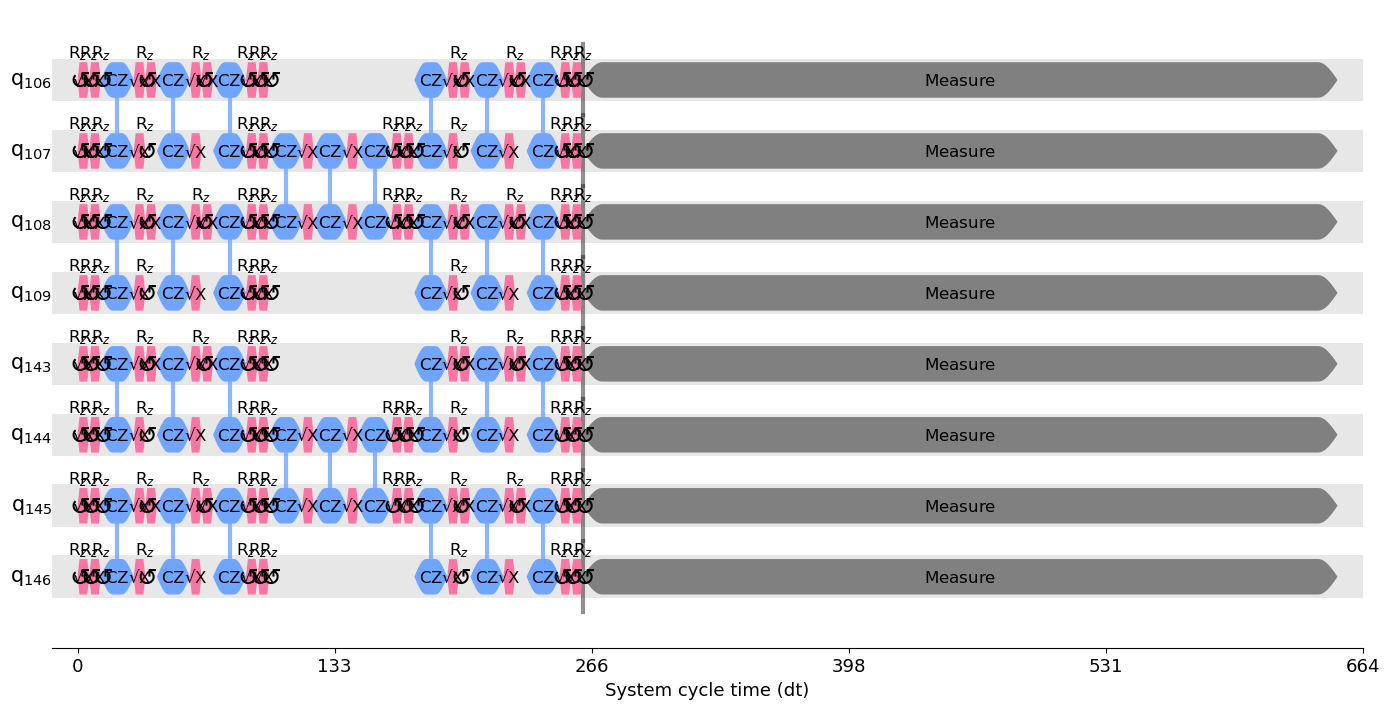

In [12]:
timeline_drawer(pubs_dict[8][1], idle_wires=False, target=fez.target)

### Saving necessary objects for repeatibility

In [13]:
# isa_circuits_dill = "extensive_benchmarking_QV_isa_circuits.dill"
# passmanagers_dill = "extensive_benchmarking_QV_passmanagers.dill"
# save_object(pubs_dict, filename=isa_circuits_dill)
# save_object(passmanagers_to_test, filename=passmanagers_dill)

## HARDWARE EXECUTION CELL. DO NOT RUN UNLESS NECESSARY

In [14]:
# hardware_job_dict = {i:{qubit:execute_on_hardware(fez, pubs_dict[qubit]) for qubit in qubits} for i in range(3)}

In [17]:
hardware_job_dict = {0: {5: 'd4u610kgk3fc73atjln0',
  8: 'd4u6115eastc73cgri5g',
  11: 'd4u611teastc73cgri7g',
  14: 'd4u612kgk3fc73atjlqg',
  17: 'd4u6137g0u6s73d9db8g',
  20: 'd4u613ng0u6s73d9db9g'},
 1: {5: 'd4u6144gk3fc73atjlt0',
  8: 'd4u614uaec6c738r0f7g',
  11: 'd4u615fg0u6s73d9dbd0',
  14: 'd4u615sgk3fc73atjlug',
  17: 'd4u616fg0u6s73d9dbf0',
  20: 'd4u616vg0u6s73d9dbg0'},
 2: {5: 'd4u617deastc73cgrif0',
  8: 'd4u617vg0u6s73d9dbhg',
  11: 'd4u618cgk3fc73atjm20',
  14: 'd4u618sgk3fc73atjm40',
  17: 'd4u619fg0u6s73d9dbk0',
  20: 'd4u619uaec6c738r0fdg'}}

In [ ]:
# hardware_job_dill = "extensive_benchmarking_QV_hardware_job.dill"
# save_object(hardware_job_dict, hardware_job_dill)

Object saved to 'extensive_benchmarking_QV_hardware_job.dill'


In [26]:
methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

isa_circuits_dict = load_object("extensive_benchmarking_QV_isa_circuits.dill")
hardware_job_dict = load_object("extensive_benchmarking_QV_hardware_job.dill")


noiseless_backend = AerSimulator()

noiseless_pub = [(isa_circuits_dict[qubit][0]) for qubit in qubits]


with Batch(backend=noiseless_backend) as batch:
    noiseless_sampler = naked_sampler(mode=batch)
    noiseless_job = noiseless_sampler.run(noiseless_pub, shots=4096)
    noiseless_result = noiseless_job.result()

Object loaded from 'extensive_benchmarking_QV_isa_circuits.dill'
Object loaded from 'extensive_benchmarking_QV_hardware_job.dill'


In [27]:
isa_circuits_dict

{5: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbe9025a90>,
 8: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbc2bacb10>,
 11: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbb9abb210>,
 14: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbc2c74610>,
 17: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbc3501a50>,
 20: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbc906f850>,
  <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x78dbc983a290>]}

In [28]:
simulated_counts = { noiseless_result[i].data.meas.num_bits:noiseless_result[i].data.meas.get_counts() for i in range(len(noiseless_result)) }
simulated_counts

{5: {'01100': 425,
  '01110': 66,
  '00100': 1326,
  '00101': 562,
  '00001': 15,
  '00111': 612,
  '01101': 181,
  '00110': 276,
  '10100': 72,
  '01000': 82,
  '01111': 206,
  '01011': 40,
  '00000': 29,
  '01001': 39,
  '10000': 22,
  '10111': 35,
  '10001': 11,
  '01010': 17,
  '10101': 31,
  '10011': 20,
  '10110': 6,
  '11110': 1,
  '00011': 7,
  '11100': 6,
  '10010': 4,
  '00010': 3,
  '11111': 2},
 8: {'10101100': 105,
  '00100101': 45,
  '00001101': 20,
  '00111111': 140,
  '00110100': 41,
  '01111110': 65,
  '10101111': 130,
  '00101101': 71,
  '01011011': 4,
  '00101111': 132,
  '01101111': 115,
  '10100100': 19,
  '00010101': 10,
  '00111011': 13,
  '00001110': 37,
  '11011011': 6,
  '01111111': 101,
  '10100010': 8,
  '01101100': 16,
  '11101111': 113,
  '01001101': 68,
  '10001101': 26,
  '01100111': 63,
  '01101010': 11,
  '01100110': 42,
  '00101100': 98,
  '01001111': 97,
  '00111101': 74,
  '11011101': 7,
  '00011000': 1,
  '01011101': 52,
  '00100111': 80,
  '001111

In [53]:

def store_data(service, job_dict, simulated, valid_methods):
    
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "simulated_counts"] + valid_methods + ["hellinger_fidelity(simulated)"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
            shots = result[0].data.meas.num_shots
            data_list.append(shots)
            
            # 3 Simulated_counts
            simulated_counts = simulated[qubit]
            data_list.append(simulated_counts)

            # 4 storing 
            for i in range(len(valid_methods)):
                data_list.append(result[i].data.meas.get_counts())


            # 5 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
            data_list += get_fidelity_for_circuit(simulated_counts, [result[i].data.meas.get_counts() for i in range(len(valid_methods))])

        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [54]:
experiment_results = store_data(service, hardware_job_dict, simulated_counts, valid_methods)

In [55]:
experiment_results.to_csv("Fez-QV-extensive-benchmarking-sampler.csv", index=False)

## Data Analysis

In [2]:
qubits = [5, 8, 11, 14, 17, 20]

methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

In [4]:
import ast
import pandas as pd
import numpy as np
# Read the CSV file
df = pd.read_csv("Fez-QV-extensive-benchmarking-sampler.csv")

# List of columns that contain string representations of dictionaries
# Based on the columns shown in your traceback
cols_to_eval = df.columns

def safe_literal_eval(val):
    """
    Safely evaluate a string containing a Python literal.
    Returns the original value if it's not a string or if evaluation fails.
    """
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return val
    return val

# Apply the conversion only to the relevant columns
for col in cols_to_eval:
    if col in df.columns:
        df[col] = df[col].apply(safe_literal_eval)

# Verify the data types
df.head()


,iteration,job_id,Qubit,shots,simulated_counts,none,asap,alap,asap+dd+xx,alap+dd+xx,alap+dd+xpxm,asap+dd+xpxm,asap+dd+xy,alap+dd+xy,hellinger_fidelity(simulated)
0,0,d4u610kgk3fc73atjln0,5,4096,"{'01100': 425, '01110': 66, '00100': 1326, '00...","{'00100': 1271, '00111': 573, '10100': 105, '0...","{'10100': 93, '00111': 517, '00100': 1272, '01...","{'01100': 381, '00100': 1215, '00101': 547, '0...","{'01111': 211, '00100': 1227, '00111': 571, '0...","{'00100': 1219, '01101': 171, '00111': 592, '0...","{'01100': 401, '01110': 73, '00100': 1308, '01...","{'00100': 1153, '00110': 225, '10100': 100, '0...","{'01010': 11, '00100': 1292, '00110': 262, '00...","{'01101': 193, '10111': 45, '00101': 506, '001...","[0.9820689006891911, 0.9752518118210182, 0.979..."
1,0,d4u6115eastc73cgri5g,8,4096,"{'10101100': 105, '00100101': 45, '00001101': ...","{'10100010': 10, '00101111': 133, '01111111': ...","{'00111111': 109, '01111110': 63, '00100111': ...","{'11001000': 2, '01011100': 8, '00110110': 19,...","{'01000110': 11, '00010000': 7, '10101111': 12...","{'00011000': 5, '11101111': 66, '11011111': 6,...","{'11100010': 11, '01111110': 70, '01111111': 7...","{'00100011': 11, '10101110': 54, '00101000': 2...","{'01100011': 10, '00110110': 33, '11111111': 1...","{'01101111': 59, '01111110': 67, '01100101': 1...","[0.9426751465936184, 0.9440350040694329, 0.942..."
2,0,d4u611teastc73cgri7g,11,4096,"{'01001110101': 2, '01001111100': 4, '11010100...","{'01100000100': 5, '10001100100': 10, '1101111...","{'01001110011': 33, '01110010000': 3, '1000100...","{'10001010011': 26, '01100011001': 6, '1001010...","{'00011111010': 1, '00011000101': 10, '1001101...","{'10001110010': 7, '00101000110': 2, '11001010...","{'11000000011': 1, '10011100101': 6, '10001100...","{'10001010001': 46, '11011000101': 16, '110011...","{'01001110110': 4, '10001001100': 12, '1001000...","{'01001110000': 8, '10000010110': 3, '01011001...","[0.7401144900352353, 0.7496664425691222, 0.742..."
3,0,d4u612kgk3fc73atjlqg,14,4096,"{'11111010101101': 1, '10000011001101': 1, '10...","{'00000000101000': 1, '00100001001100': 1, '11...","{'00110101001110': 3, '10110101001101': 5, '01...","{'01111111110101': 1, '01010101011001': 1, '01...","{'11000101101100': 9, '00110101110101': 1, '00...","{'11011101011101': 1, '11001101101100': 4, '10...","{'11100101101100': 10, '10010100111000': 1, '1...","{'10100011101011': 1, '00110001101101': 1, '11...","{'10011101000101': 1, '11010101101101': 4, '00...","{'01110011000111': 1, '11000011011010': 1, '11...","[0.28617482250170484, 0.2935787379662414, 0.28..."
4,0,d4u6137g0u6s73d9db8g,17,4096,"{'01001101001111000': 1, '10110100010111000': ...","{'01110001001111010': 1, '11010110010010100': ...","{'00111001110100001': 1, '01110100010100000': ...","{'10010001001111000': 1, '11101101011111001': ...","{'01111000110100100': 1, '01111101011010000': ...","{'01110101010110100': 1, '10011000001000100': ...","{'10111000110000000': 1, '11001100001111010': ...","{'00101101010100000': 1, '01001101100100010': ...","{'01001001000001011': 1, '10011101011011100': ...","{'10101100010000010': 1, '10111000011100010': ...","[0.10668154422545029, 0.09463413064390058, 0.1..."


In [5]:
iterations = 3

print("..............................................................................................")
for i in range(iterations):
    print(df[df['Qubit']==5].iloc[i, 14])
print(["hellinger_fidelity(simulated)"])


..............................................................................................
[0.9820689006891911, 0.9752518118210182, 0.9791063301401415, 0.9750948637191829, 0.9804245186878797, 0.9817482307357465, 0.9744414246859221, 0.9833151095731799, 0.9849775604390788]
[0.9812500814002106, 0.9759667995185998, 0.9806873113545256, 0.9744050229209635, 0.9797303090863769, 0.9813339594656597, 0.9779904456850849, 0.9830717291773198, 0.9832043786438375]
[0.9783720711596029, 0.9754769156628723, 0.9791791335139117, 0.9770546146184207, 0.9773833754238521, 0.9765900458777562, 0.9793015933047179, 0.9827452514949246, 0.9824259796281682]
['hellinger_fidelity(simulated)']


In [6]:
def get_labels_and_fidelity_data(data, qubit, valid_methods):

    # Returns valid_methods, output_list
    
    qubit_df = data[data["Qubit"] == qubit]

    output_dict = {method:[] for method in valid_methods}
    
    for i in range(iterations):
        
        alt_hf = qubit_df.iloc[i, 14]
        
        # print(f"For qubit: {qubit} \n Hellinger Fidelity wrt ideal (simulated, no_dd, dd):\n {hf} \n Hellinger Fidelity wrt simulated (no_dd, dd):\n {alt_hf} \n")
        for method in valid_methods:
            output_dict[method].append(alt_hf[valid_methods.index(method)])

            
    return output_dict



In [7]:
fidelity_dict = {qubit:get_labels_and_fidelity_data(df, qubit, valid_methods) for qubit in qubits}
fidelity_dict


{5: {'none': [0.9820689006891911, 0.9812500814002106, 0.9783720711596029],
  'asap': [0.9752518118210182, 0.9759667995185998, 0.9754769156628723],
  'alap': [0.9791063301401415, 0.9806873113545256, 0.9791791335139117],
  'asap+dd+xx': [0.9750948637191829, 0.9744050229209635, 0.9770546146184207],
  'alap+dd+xx': [0.9804245186878797, 0.9797303090863769, 0.9773833754238521],
  'alap+dd+xpxm': [0.9817482307357465, 0.9813339594656597, 0.9765900458777562],
  'asap+dd+xpxm': [0.9744414246859221, 0.9779904456850849, 0.9793015933047179],
  'asap+dd+xy': [0.9833151095731799, 0.9830717291773198, 0.9827452514949246],
  'alap+dd+xy': [0.9849775604390788, 0.9832043786438375, 0.9824259796281682]},
 8: {'none': [0.9426751465936184, 0.9446022159555811, 0.9421451004774213],
  'asap': [0.9440350040694329, 0.9426906170530892, 0.9472892326074976],
  'alap': [0.942180976319912, 0.945900130173028, 0.9346304038134872],
  'asap+dd+xx': [0.9447060316963998, 0.9462021429697389, 0.9446999305462026],
  'alap+dd+xx

In [8]:
average_fidelity_dict = {qubit:{method:np.mean(fidelity_dict[qubit][method]) for method in valid_methods}  for qubit in qubits}

average_fidelity_dict

{5: {'none': 0.9805636844163349,
  'asap': 0.9755651756674967,
  'alap': 0.9796575916695263,
  'asap+dd+xx': 0.9755181670861891,
  'alap+dd+xx': 0.9791794010660363,
  'alap+dd+xpxm': 0.9798907453597208,
  'asap+dd+xpxm': 0.9772444878919083,
  'asap+dd+xy': 0.9830440300818081,
  'alap+dd+xy': 0.9835359729036949},
 8: {'none': 0.9431408210088735,
  'asap': 0.9446716179100066,
  'alap': 0.9409038367688091,
  'asap+dd+xx': 0.945202701737447,
  'alap+dd+xx': 0.9464086766053342,
  'alap+dd+xpxm': 0.9462194076237868,
  'asap+dd+xpxm': 0.940584555697389,
  'asap+dd+xy': 0.9451960525121406,
  'alap+dd+xy': 0.9408609062013437},
 11: {'none': 0.7420962985800338,
  'asap': 0.7458464486435076,
  'alap': 0.7479737841883356,
  'asap+dd+xx': 0.7389602982701997,
  'alap+dd+xx': 0.7447928812645314,
  'alap+dd+xpxm': 0.7381486992242404,
  'asap+dd+xpxm': 0.7392700393032404,
  'asap+dd+xy': 0.7449778580285562,
  'alap+dd+xy': 0.7350292986260413},
 14: {'none': 0.28086300620531524,
  'asap': 0.289717982036

In [9]:


def get_all_average_hf_plot_data(qubit):
    plot_methods = ["none", "asap", "alap", "asap+dd+xx", "alap+dd+xx", "asap+dd+xpxm", "alap+dd+xpxm", "asap+dd+xy", "alap+dd+xy"]
    labels = plot_methods

    data_for_label = []
    for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

    return labels, data_for_label


def get_asap_average_hf_plot_data(qubit):
    plot_methods = ["none", "asap", "asap+dd+xx", "asap+dd+xpxm", "asap+dd+xy"]
    labels = plot_methods

    data_for_label = []
    for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

    return labels, data_for_label

def get_alap_average_hf_plot_data(qubit):
    plot_methods = ["none", "alap", "alap+dd+xx", "alap+dd+xpxm", "alap+dd+xy"]
    labels = plot_methods

    data_for_label = []
    for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

    return labels, data_for_label


def plot_alap_hf_for_qubit(qubit, ax):

    labels, data = get_alap_average_hf_plot_data(qubit)


    ax.plot(range(len(data)), data, marker='o', linestyle='--', label=[qubit])

    ax.minorticks_on()
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, rotation=75)
    ax.legend()
    
    ax.grid(True)



def plot_asap_hf_for_qubit(qubit, ax):

    labels, data = get_asap_average_hf_plot_data(qubit)


    ax.plot(range(len(data)), data, marker='o', linestyle='--', label=[qubit])

    ax.minorticks_on()
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, rotation=75)
    ax.legend()
    
    ax.grid(True)



def plot_all_hf_for_qubit(qubit, ax):
    
    labels, data = get_all_average_hf_plot_data(qubit)


    ax.plot(range(len(data)), data, marker='o', linestyle='--', label=[qubit])

    ax.minorticks_on()
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, rotation=75)
    ax.legend()
    
    ax.grid(True)


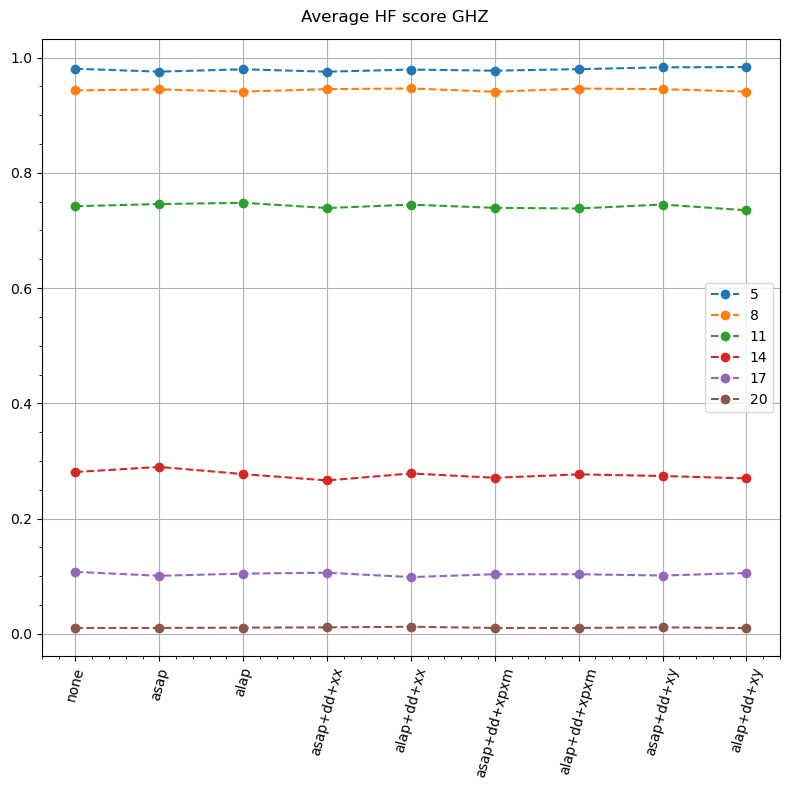

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8), sharex=True)

plot_all_hf_for_qubit(5  , ax)
plot_all_hf_for_qubit(8  , ax)
plot_all_hf_for_qubit(11 , ax)
plot_all_hf_for_qubit(14 , ax)
plot_all_hf_for_qubit(17 , ax)
plot_all_hf_for_qubit(20 , ax)


fig.suptitle("Average HF score GHZ")
fig.tight_layout()

fig.savefig("Fez_DD_Average_HF_score_QV.png")